Exploratory data analysis (EDA) is a crucial component of data science which allows you to understand the basics of what your data looks like and what kinds of questions might be answered. For this task, we are going to clean, sanitise and explore our data. Using the automobile dataset, complete the steps outlined in this notebook by writing code in the cells.

In [ ]:
# Import libraries

import numpy as np
import pandas as pd
import seaborn as sns

from datetime import datetime
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# Load the movies dataset
automobiles_df = pd.read_csv('automobile.txt')

### Data Cleansing
#### Clean the data

Identify columns that are redundant or unnecessary. It is always easier to make your decisions based on data which is relevant and concise. Remove the following columns `['normalized-losses', 'symboling']` from the data set as they will not be used in the analysis.

In [ ]:
automobiles_df = automobiles_df.drop(columns=['normalized-losses', 'symboling'])
automobiles_df.head()


,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


#### Remove rows with missing data

Some automobiles in the database have missing values which implies that their values have not been recorded or some information is missing. Discard such entries from the dataframe.

In [ ]:
# Replace '?' placeholders with NaN, then drop any row containing missing values
automobiles_df = automobiles_df.replace('?', np.nan)
automobiles_df = automobiles_df.dropna()
print(f"Rows after removing missing data: {len(automobiles_df)}")


Rows after removing missing data: 193


Using `replace()` to swap the `?` placeholder values with `NaN`, then `dropna()` to remove any rows that contain missing values.

#### Remove any duplicate rows

In [ ]:
automobiles_df = automobiles_df.drop_duplicates()
print(f"Rows after removing duplicates: {len(automobiles_df)}")

Using `drop_duplicates()` to remove any duplicate rows from the DataFrame.

Change columns with numerical data column to an integer data type using numpy’s `int64` method.

In [ ]:
int_cols = ['engine-size', 'curb-weight', 'horsepower', 'peak-rpm',
            'city-mpg', 'highway-mpg', 'price']
automobiles_df[int_cols] = automobiles_df[int_cols].astype(np.int64)

float_cols = ['wheel-base', 'length', 'width', 'height', 'bore', 'stroke', 'compression-ratio']
automobiles_df[float_cols] = automobiles_df[float_cols].astype(float)

automobiles_df.dtypes


make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm               int64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object

Using `astype()` to convert the integer columns to `int64` and the float columns to `float` data types. This is necessary because the `?` placeholders caused those columns to be read in as strings (`object` type) when the file was loaded.

### Finding Certain Categories
Locate all automobiles in the "hatchback" genre.

In [ ]:
# Create a dataframe with all the cars in the "hatchback" category
hatchback_cars = automobiles_df[automobiles_df['body-style'] == 'hatchback']
hatchback_cars


,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.00,154,5000,19,26,16500
18,chevrolet,gas,std,two,hatchback,fwd,front,88.4,141.1,60.3,...,61,2bbl,2.91,3.03,9.50,48,5100,47,53,5151
19,chevrolet,gas,std,two,hatchback,fwd,front,94.5,155.9,63.6,...,90,2bbl,3.03,3.11,9.60,70,5400,38,43,6295
21,dodge,gas,std,two,hatchback,fwd,front,93.7,157.3,63.8,...,90,2bbl,2.97,3.23,9.41,68,5500,37,41,5572
22,dodge,gas,std,two,hatchback,fwd,front,93.7,157.3,63.8,...,90,2bbl,2.97,3.23,9.40,68,5500,31,38,6377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,toyota,gas,std,four,hatchback,fwd,front,102.4,175.6,66.5,...,122,mpfi,3.31,3.54,8.70,92,4200,27,32,9988
177,toyota,gas,std,four,hatchback,fwd,front,102.4,175.6,66.5,...,122,mpfi,3.31,3.54,8.70,92,4200,27,32,11248
178,toyota,gas,std,two,hatchback,rwd,front,102.9,183.5,67.7,...,171,mpfi,3.27,3.35,9.30,161,5200,20,24,16558
179,toyota,gas,std,two,hatchback,rwd,front,102.9,183.5,67.7,...,171,mpfi,3.27,3.35,9.30,161,5200,19,24,15998


### Now onto the exploration

#### Identify relationships between variables (features)


#### Which are the 5 most expensive cars?

How do the most expensive and cheapest cars compare? Exploring the most expensive cars and how thier price relates to their fuel economy (mpg or miles per gallon)

In [ ]:
top5_expensive = automobiles_df.nlargest(5, 'price')[['make', 'body-style', 'price', 'city-mpg', 'highway-mpg']]
print("5 Most Expensive Cars:")
print(top5_expensive.to_string(index=False))


5 Most Expensive Cars:
         make  body-style  price  city-mpg  highway-mpg
mercedes-benz     hardtop  45400        14           16
          bmw       sedan  41315        16           22
mercedes-benz       sedan  40960        14           16
      porsche convertible  37028        17           25
          bmw       sedan  36880        15           20


Using `nlargest()` to find the 5 most expensive cars based on the `price` column. Only the relevant columns are selected to keep the output readable.

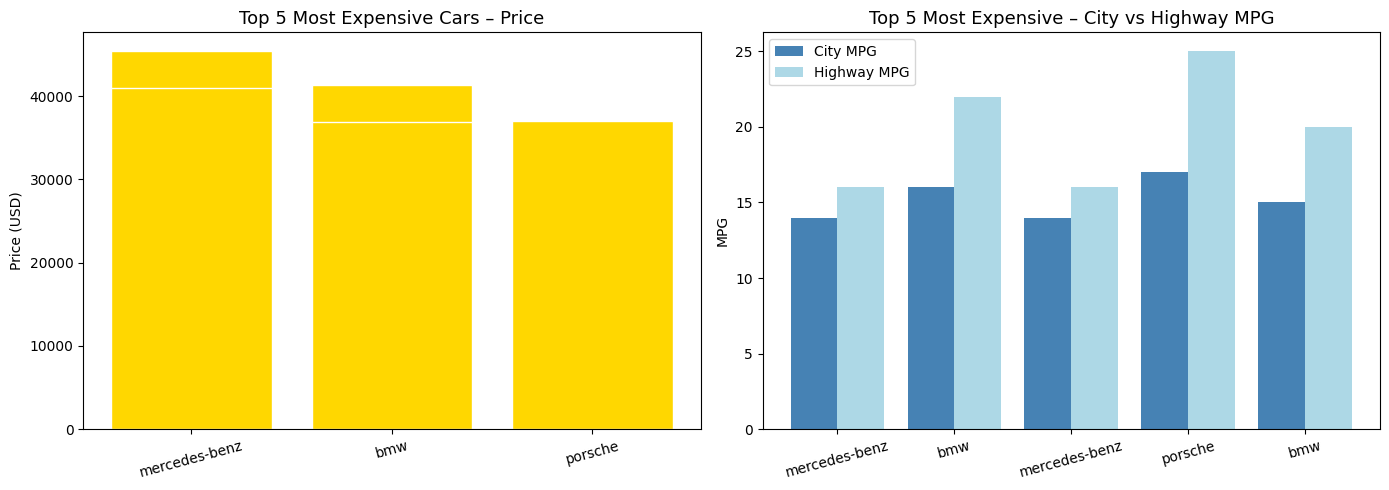

In [ ]:
# Visualise the top 5 most expensive cars
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [row['make'] for _, row in top5_expensive.iterrows()]
# Bar chart for price
axes[0].bar(labels, top5_expensive['price'], color='gold', edgecolor='white')
axes[0].set_title('Top 5 Most Expensive Cars – Price')
axes[0].set_ylabel('Price (USD)')
axes[0].tick_params(axis='x', rotation=15)
# Bar chart for city vs highway MPG
x = range(len(top5_expensive))
axes[1].bar([i - 0.2 for i in x], top5_expensive['city-mpg'],    width=0.4, label='City MPG',    color='steelblue')
axes[1].bar([i + 0.2 for i in x], top5_expensive['highway-mpg'], width=0.4, label='Highway MPG', color='lightblue')
axes[1].set_title('Top 5 Most Expensive – City vs Highway MPG')
axes[1].set_ylabel('MPG')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()


Using `plt.subplots(1, 2)` to create two side-by-side charts. The left chart uses `bar()` to plot the price of each car. The right chart uses two `bar()` calls offset by ±0.2 to create a grouped bar chart comparing city vs highway MPG for the same cars.

#### Which manufacturer builds the most fuel efficient vehicles?

Compare the average mpg for each vehicle manufacture's vehicles and create a bar plot

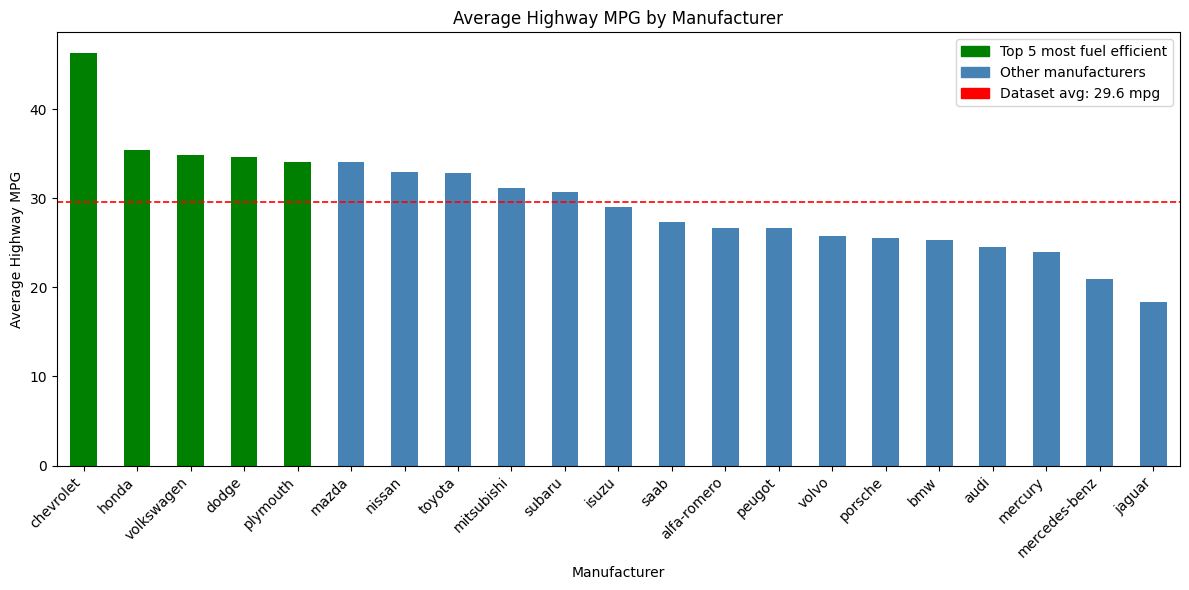

In [ ]:
import matplotlib.patches as mpatches

avg_mpg = automobiles_df.groupby('make')['highway-mpg'].mean().sort_values(ascending=False)

colors = ['green' if i < 5 else 'steelblue' for i in range(len(avg_mpg))]
# Bar cart for average highway MPG by manufacturer
plt.figure(figsize=(12, 6))
avg_mpg.plot(kind='bar', color=colors)
plt.axhline(avg_mpg.mean(), color='red', linestyle='--', linewidth=1.2,
            label=f'Dataset avg: {avg_mpg.mean():.1f} mpg')
plt.title('Average Highway MPG by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Average Highway MPG')
plt.xticks(rotation=45, ha='right')
# Create custom legend
top5_patch = mpatches.Patch(color='green', label='Top 5 most fuel efficient')
other_patch = mpatches.Patch(color='steelblue', label='Other manufacturers')
avg_line = mpatches.Patch(color='red', label=f'Dataset avg: {avg_mpg.mean():.1f} mpg')
plt.legend(handles=[top5_patch, other_patch, avg_line])

plt.tight_layout()
plt.show()


Using `groupby('make')['highway-mpg'].mean()` to calculate the average highway MPG per manufacturer. The top 5 bars are coloured green to show the top five in MPG. `axhline()` draws a horizontal dashed line at the dataset-wide average. `mpatches.Patch` is used to create custom legend entries since the colours aren't tied to a standard plot legend.

#### Which vehicles have the largest engine capacity.
Sort the dataframe based on the engine-size column.

In [ ]:
largest_engines = automobiles_df.sort_values('engine-size', ascending=False)[['make', 'body-style', 'engine-size', 'horsepower', 'price']] 
largest_engines.head(10)


,make,body-style,engine-size,horsepower,price
49,jaguar,sedan,326,262,36000
73,mercedes-benz,sedan,308,184,40960
74,mercedes-benz,hardtop,304,184,45400
47,jaguar,sedan,258,176,32250
48,jaguar,sedan,258,176,35550
71,mercedes-benz,sedan,234,155,34184
72,mercedes-benz,convertible,234,155,35056
17,bmw,sedan,209,182,36880
16,bmw,sedan,209,182,41315
15,bmw,sedan,209,182,30760


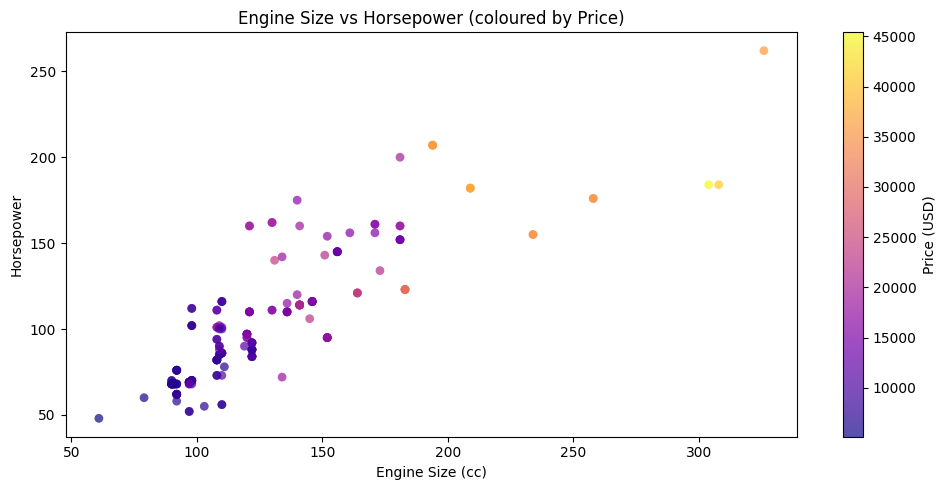

In [ ]:

# Scatter plot: engine size vs horsepower, colour-coded by price
plt.figure(figsize=(10, 5))
scatter = plt.scatter(automobiles_df['engine-size'], automobiles_df['horsepower'],
                      c=automobiles_df['price'], cmap='plasma', alpha=0.7, edgecolors='none', s=40)
cbar = plt.colorbar(scatter)
cbar.set_label('Price (USD)')
plt.title('Engine Size vs Horsepower (coloured by Price)')
plt.xlabel('Engine Size (cc)')
plt.ylabel('Horsepower')
plt.tight_layout()
plt.show()


For engine size vs horsepower used a scatter plot with price as the colour dimension to show how engine size and horsepower relate to price.

#### Which vehicle manufacturer has the most car models in the dataset

In [ ]:
models_per_make = automobiles_df.groupby('make').size().sort_values(ascending=False)
print("Number of car models per manufacturer:")
print(models_per_make.to_string())
print(f"\nManufacturer with the most models: {models_per_make.idxmax()} ({models_per_make.max()} models)")


Number of car models per manufacturer:
make
toyota           32
nissan           18
mitsubishi       13
honda            13
subaru           12
mazda            12
volkswagen       12
volvo            11
peugot           11
bmw               8
mercedes-benz     8
dodge             8
plymouth          7
audi              6
saab              6
porsche           4
alfa-romero       3
chevrolet         3
jaguar            3
isuzu             2
mercury           1

Manufacturer with the most models: toyota (32 models)


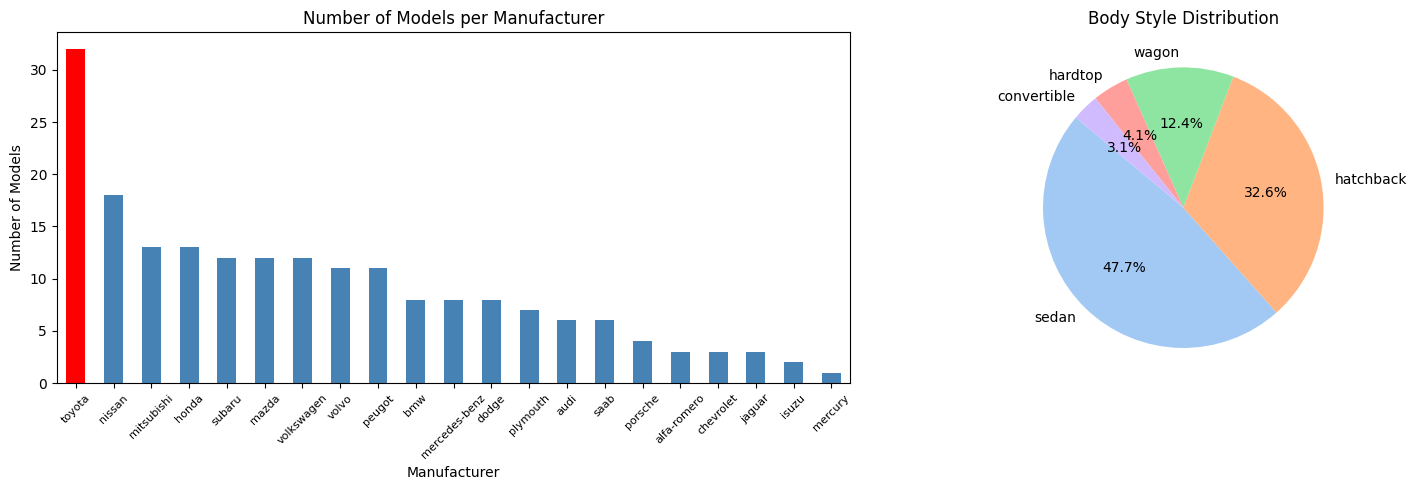

In [ ]:
# Bar chart for models per manufacturer
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bar_colors = ['red'] + ['steelblue'] * (len(models_per_make) - 1)
models_per_make.plot(kind='bar', ax=axes[0], color=bar_colors)
axes[0].set_title('Number of Models per Manufacturer')
axes[0].set_xlabel('Manufacturer')
axes[0].set_ylabel('Number of Models')
axes[0].tick_params(axis='x', labelsize=8, rotation=45)
# Pie chart for body style distribution
body_style_counts = automobiles_df['body-style'].value_counts()
axes[1].pie(body_style_counts.values, labels=body_style_counts.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('pastel', len(body_style_counts)))
axes[1].set_title('Body Style Distribution')

plt.tight_layout()
plt.show()


The bar chart uses `groupby().size()` to count models per manufacturer — the top bar is coloured red to highlight Toyota. The pie chart uses `value_counts()` to count each body style, with `autopct='%1.1f%%'` to show percentage labels on the slices and `sns.color_palette('pastel')` to give each slice a distinct colour.